In [1]:
from src.deep_learning.op import MULTIPLY
from src.deep_learning.op import PLUS
from src.deep_learning.value import Value
from src.deep_learning.util import draw

a = Value(2, label='a')
b = Value(3, label='b')
c = Value(label='c', children=[a, b], op=PLUS)

d = Value(5, label='d')
e = Value(6, label='e')
f = Value(label='f', children=[d, e], op=MULTIPLY)

L = Value(label='L', children=[c, f], op=PLUS)

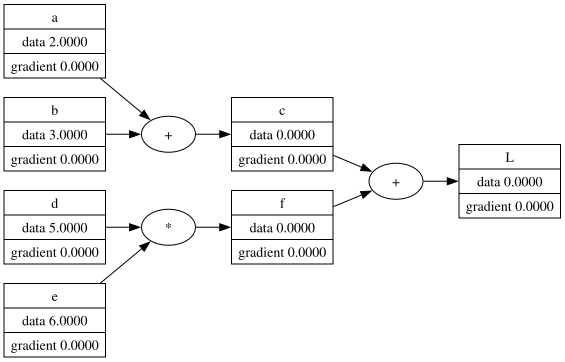

In [ ]:
draw(L)

In [ ]:
L.forward()

Value({'data': 35.0, 'label': 'L', 'op': +, 'children': [Value({'data': 5.0, 'label': 'c', 'op': +, 'children': [Value({'data': 2.0, 'label': 'a', 'op': None, 'children': [], 'gradient': 0.0}), Value({'data': 3.0, 'label': 'b', 'op': None, 'children': [], 'gradient': 0.0})], 'gradient': 0.0}), Value({'data': 30.0, 'label': 'f', 'op': *, 'children': [Value({'data': 5.0, 'label': 'd', 'op': None, 'children': [], 'gradient': 0.0}), Value({'data': 6.0, 'label': 'e', 'op': None, 'children': [], 'gradient': 0.0})], 'gradient': 0.0})], 'gradient': 0.0})

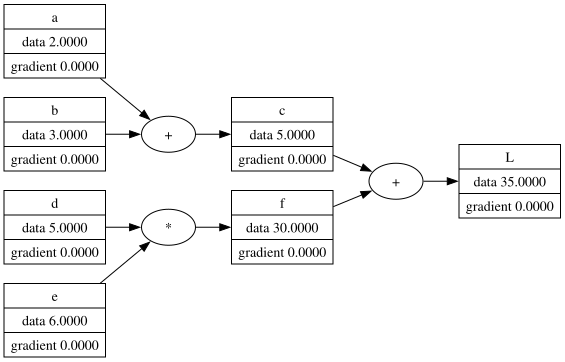

In [ ]:
draw(L)

In [ ]:
L.gradient = 1.0
L.backward()

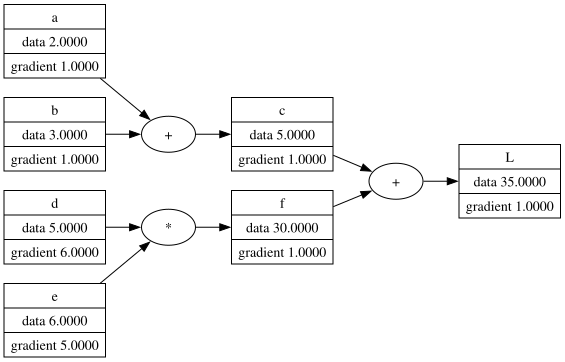

In [ ]:
draw(L)

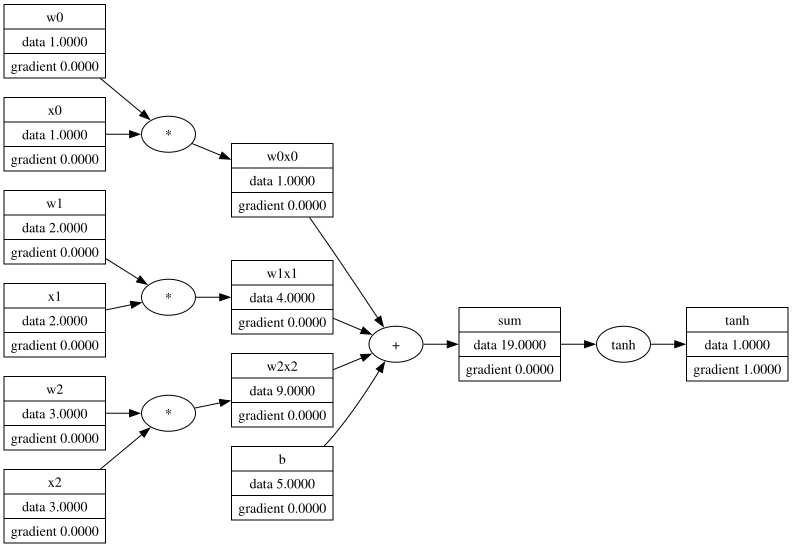

In [ ]:
from src.deep_learning.neuron import Neuron
from src.deep_learning.value import Value
from src.deep_learning.util import draw
from src.deep_learning.op import TANH

neuron = Neuron(
    weights=[1.0, 2.0, 3.0],
    bias=5.0,
    activation=TANH,
)
value = neuron.forward(
    inputs=[1.0, 2.0, 3.0],
)
assert value.data == TANH.forward([1.0 ** 2 + 2.0 ** 2 + 3.0 ** 2 + 5.0])

value.gradient = 1.0
value.backward()
draw(value)

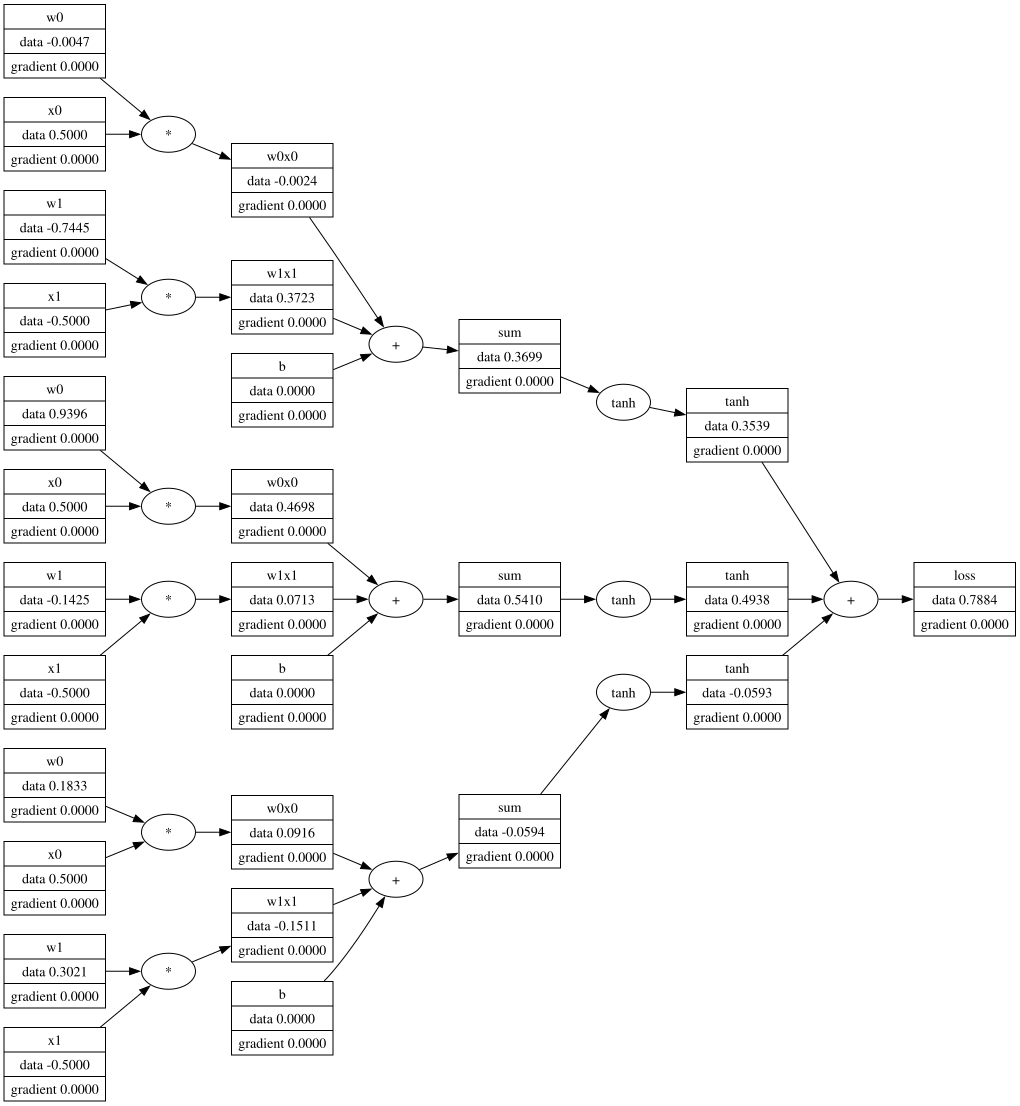

In [ ]:
from src.deep_learning.op import PLUS
from src.deep_learning.layer import get_random_layer

layer = get_random_layer(3, 2, TANH)
inputs = [0.5, -0.5]
outputs = layer.forward(inputs)

loss = Value(
    data=PLUS.forward([output.data for output in outputs]),
    label='loss',
    op=PLUS,
    children=outputs,
)

draw(loss)

In [ ]:
from src.deep_learning.multi_layer_perceptron import MultiLayerPerceptron

class Data:
  def __init__(self, inputs: list[float], outputs: list[float]):
    self.inputs = inputs
    self.outputs = outputs

data = [
    Data([2.0, 3.0, -1.0,], [1.0]),
    Data([3.0, -1.0, 0.5], [-1.0]),
    Data([0.5, 1.0, 1.0], [-1.0]),
    Data([1.0, 1.0, -1.0], [1.0]),
]

multi_layer_perceptron = MultiLayerPerceptron(
    layers=[
        get_random_layer(4, 3, TANH),
        get_random_layer(4, 4, TANH),
        get_random_layer(1, 4, TANH),
    ],
)

In [ ]:
losses: list[float] = []

In [ ]:
for i in range(10000):
  # compute loss
  predicted_outputs = [multi_layer_perceptron.forward(d.inputs) for d in data]
  sum_squared_difference_value = Value(0.0)
  for output, predicted_output in zip([d.outputs for d in data], predicted_outputs):
    output_value = Value(output[0])
    predicted_output_value = predicted_output[0]
    difference_value = output_value + (predicted_output_value * -1)
    squared_difference_value = difference_value ** 2
    sum_squared_difference_value += squared_difference_value
  loss = sum_squared_difference_value * (1 / len(predicted_outputs))
  loss.label = 'loss'

  losses.append(loss.data)

  loss.gradient = 1.0

  # zero gradients of parameters
  for layer in multi_layer_perceptron.layers:
    for neuron in layer.neurons:
      for weight_value in neuron.weight_values:
        weight_value.gradient = 0
      neuron.bias_value.gradient = 0

  loss.backward()

  # update parameters
  alpha = 0.01
  for layer in multi_layer_perceptron.layers:
    for neuron in layer.neurons:
      for weight_value in neuron.weight_values:
        weight_value.data = weight_value.data - weight_value.gradient * alpha
      neuron.bias_value.data = neuron.bias_value.data - neuron.bias_value.gradient * alpha

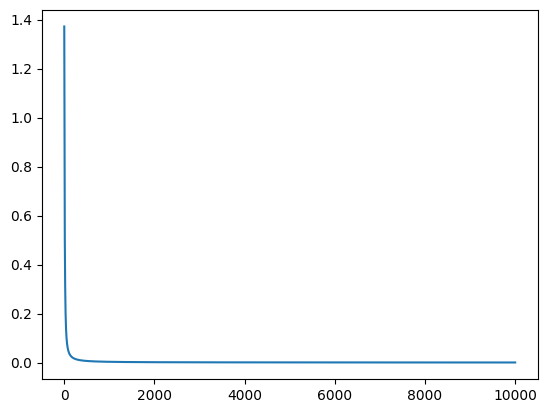

In [ ]:
import matplotlib.pyplot as plt

plt.plot(losses)

In [ ]:
[multi_layer_perceptron.forward(d.inputs) for d in data]

[[Value({'data': 0.9858809739138509, 'label': 'tanh', 'op': tanh, 'children': [Value({'data': 2.4731473273102496, 'label': 'sum', 'op': +, 'children': [Value({'data': -0.16339543207543414, 'label': 'w0x0', 'op': *, 'children': [Value({'data': -0.49459304991075886, 'label': 'w0', 'op': None, 'children': [], 'gradient': 0.0003304198226248108}), Value({'data': 0.33036338077317534, 'label': 'tanh', 'op': tanh, 'children': [Value({'data': 0.34323609831640584, 'label': 'sum', 'op': +, 'children': [Value({'data': 0.7538769904438217, 'label': 'w0x0', 'op': *, 'children': [Value({'data': 0.8700397857607765, 'label': 'w0', 'op': None, 'children': [], 'gradient': 5.63968369281746e-05}), Value({'data': 0.8664856513252666, 'label': 'tanh', 'op': tanh, 'children': [Value({'data': 1.318801829037196, 'label': 'sum', 'op': +, 'children': [Value({'data': 1.6308407134068008, 'label': 'w0x0', 'op': *, 'children': [Value({'data': 0.8154203567034004, 'label': 'w0', 'op': None, 'children': [], 'gradient': 0.